# Reranker Evaluation — Cross-Encoder on Top of the Cosine-Similarity Retriever

The previous evaluation (`retriever_evaluation.ipynb`) found a ~42-point gap between Hit Rate@1 (41%) and Hit Rate@10 (83%): the correct document is usually *retrieved*, just not *ranked first*. That's the textbook case for a **reranker** — it doesn't need to find new candidates, it just needs to re-order the ones the retriever already found.

This notebook:

1. Reuses the exact same setup, golden set, retrieval function, and metric functions as the baseline notebook (same variable/function names throughout) so the comparison is apples-to-apples.
2. Adds a **cross-encoder reranking stage** on top of the existing retriever.
3. Evaluates the reranked pipeline with the identical metrics, on the identical queries.
4. Compares baseline vs. reranked side by side — quality, latency, and which specific queries got fixed (or broken).


## 0. Setup

In [2]:
import os
import json
import time
import random
from pathlib import Path
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import chromadb
from sentence_transformers import SentenceTransformer, CrossEncoder

import warnings
warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


## 1. Reconnect to the Existing Vector Store

Identical to the baseline notebook — we reuse the already-persisted retriever, not a new one.

In [3]:
EMBEDDING_MODEL_NAME = "BAAI/bge-small-en-v1.5"   # must match the model used at ingestion time
PERSIST_DIRECTORY = "../data/vector_store"
COLLECTION_NAME = "json_qa_documents"

print(f"Loading embedding model: {EMBEDDING_MODEL_NAME} ...")
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
print("Model loaded.")

client = chromadb.PersistentClient(path=PERSIST_DIRECTORY)
collection = client.get_collection(name=COLLECTION_NAME)

print(f"Connected to collection '{COLLECTION_NAME}'")
print(f"Documents in collection: {collection.count()}")


Loading embedding model: BAAI/bge-small-en-v1.5 ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1826.46it/s]


Model loaded.
Connected to collection 'json_qa_documents'
Documents in collection: 2964


## 2. Golden Evaluation Set

Identical construction to the baseline notebook: one `(query, relevant_doc_ids)` pair per corpus record, carrying `topic_group` and `flags` through for the stratified checks later.

Reranking with a cross-encoder is much more compute-heavy than the bi-encoder retrieval step (see Section 3), so `SAMPLE_SIZE` defaults to `300` here rather than the full 2,964 — you already validated in the baseline notebook that a 300-query sample tracks the full-corpus numbers closely. Set it to `None` once you're happy with the reranker and want a final full-corpus number.

In [4]:
CORPUS_PATH = Path("../data/json_files/bliss_corpus.json")

with open(CORPUS_PATH, "r", encoding="utf-8") as f:
    corpus_records = json.load(f)

print(f"Loaded {len(corpus_records)} records from corpus")

eval_set = []
for record in corpus_records:
    doc_id = record.get("doc_id")
    question = record.get("question")
    if doc_id and question:
        meta = record.get("metadata", {})
        eval_set.append({
            "query": question,
            "relevant_doc_ids": [doc_id],
            "topic_group": meta.get("topic_group", "unknown"),
            "flags": meta.get("flags", []) or [],
        })

print(f"Built {len(eval_set)} query/ground-truth pairs")

SAMPLE_SIZE = 300
if SAMPLE_SIZE and SAMPLE_SIZE < len(eval_set):
    eval_set = random.sample(eval_set, SAMPLE_SIZE)
    print(f"Sampled down to {len(eval_set)} queries for this run")

pd.DataFrame(eval_set).head()


Loaded 2964 records from corpus
Built 2964 query/ground-truth pairs
Sampled down to 300 queries for this run


,query,relevant_doc_ids,topic_group,flags
0,How does a counselor decide when to end counse...,[cc_q895_a013],treatment_and_help,[]
1,I have so many issues to address. I have a his...,[cc_q0_a023],depression_mood,[long_personal_post_question]
2,How do PANS/PANDAS symptoms differ from typica...,[nimh_pandas_03],neurodevelopmental,[]
3,I feel too scared to meet people I don't know ...,[cc_q206_a001],anxiety_stress,[]
4,When I'm in large crowds I get angry and I jus...,[cc_q159_a017],anxiety_stress,[long_personal_post_question]


## 3. Baseline Retrieval Function

Unchanged from the baseline notebook: raw top-k from the cosine-similarity retriever, no score thresholding.

In [5]:
def retrieve_for_eval(query: str, top_k: int) -> List[str]:
    """
    Retrieve the top_k document ids for a query, ranked best-first,
    with no similarity-score filtering.
    """
    query_embedding = embedding_model.encode([query])[0]
    results = collection.query(
        query_embeddings=[query_embedding.tolist()],
        n_results=top_k,
    )
    if results["ids"] and results["ids"][0]:
        return results["ids"][0]
    return []


## 4. Retrieval Metrics

Unchanged — same five functions as the baseline notebook, reused as-is for both the baseline and reranked evaluations below so the numbers are directly comparable.

In [6]:
def hit_rate_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int) -> int:
    top_k = retrieved_ids[:k]
    return int(any(doc_id in relevant_ids for doc_id in top_k))


def reciprocal_rank(retrieved_ids: List[str], relevant_ids: List[str]) -> float:
    for rank, doc_id in enumerate(retrieved_ids, start=1):
        if doc_id in relevant_ids:
            return 1.0 / rank
    return 0.0


def precision_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int) -> float:
    top_k = retrieved_ids[:k]
    if not top_k:
        return 0.0
    num_relevant_in_top_k = sum(1 for doc_id in top_k if doc_id in relevant_ids)
    return num_relevant_in_top_k / len(top_k)


def recall_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int) -> float:
    if not relevant_ids:
        return 0.0
    top_k = retrieved_ids[:k]
    num_relevant_found = sum(1 for doc_id in top_k if doc_id in relevant_ids)
    return num_relevant_found / len(relevant_ids)


def ndcg_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int) -> float:
    top_k = retrieved_ids[:k]
    dcg = 0.0
    for i, doc_id in enumerate(top_k):
        relevance = 1.0 if doc_id in relevant_ids else 0.0
        dcg += relevance / np.log2(i + 2)
    num_relevant = min(len(relevant_ids), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(num_relevant))
    return dcg / idcg if idcg > 0 else 0.0


## 5. Baseline Evaluation Run

Same loop, same variable names (`results_df`, `summary`) as the baseline notebook — run again here on this notebook's sample so the reranked comparison in Section 9 is against numbers computed in the exact same run.

In [7]:
K_VALUES = [1, 3, 5, 10]
MAX_K = max(K_VALUES)

per_query_results = []

for item in eval_set:
    query = item["query"]
    relevant_ids = item["relevant_doc_ids"]

    retrieved_ids = retrieve_for_eval(query, top_k=MAX_K)

    row = {
        "query": query,
        "relevant_doc_ids": relevant_ids,
        "retrieved_doc_ids": retrieved_ids,
        "topic_group": item.get("topic_group", "unknown"),
        "flags": item.get("flags", []),
        "is_safety_sensitive": "safety_sensitive" in item.get("flags", []),
        "reciprocal_rank": reciprocal_rank(retrieved_ids, relevant_ids),
    }
    for k in K_VALUES:
        row[f"hit_rate@{k}"] = hit_rate_at_k(retrieved_ids, relevant_ids, k)
        row[f"precision@{k}"] = precision_at_k(retrieved_ids, relevant_ids, k)
        row[f"recall@{k}"] = recall_at_k(retrieved_ids, relevant_ids, k)
        row[f"ndcg@{k}"] = ndcg_at_k(retrieved_ids, relevant_ids, k)

    per_query_results.append(row)

results_df = pd.DataFrame(per_query_results)

metric_cols = [c for c in results_df.columns if "@" in c or c == "reciprocal_rank"]
summary = results_df[metric_cols].mean().rename("score").to_frame()
summary.loc["MRR"] = results_df["reciprocal_rank"].mean()
summary = summary.drop(index="reciprocal_rank")
summary = summary.round(4)

print(f"Baseline: evaluated {len(results_df)} queries")
summary


Baseline: evaluated 300 queries


,score
hit_rate@1,0.4433
precision@1,0.4433
recall@1,0.4433
ndcg@1,0.4433
hit_rate@3,0.6400
precision@3,0.2133
recall@3,0.6400
ndcg@3,0.5565
hit_rate@5,0.7167
precision@5,0.1433


## 6. Adding a Cross-Encoder Reranker

**Why a cross-encoder fixes exactly this problem.** The current retriever is a *bi-encoder*: the query and every document are embedded independently, and similarity is just cosine distance between two fixed vectors. That's what makes it fast enough to search thousands of documents, but it also means the model never actually looks at the query and a candidate document *together* — it can't reason about their relationship, only compare precomputed summaries of each in isolation. A *cross-encoder* feeds the query and a candidate document into the model **together** in a single forward pass, so it can directly judge how well they match. That's far more accurate, but it's also too slow to run against the whole corpus — so the standard pattern is **retrieve-then-rerank**: use the fast bi-encoder to pull a modest candidate pool (say, top 20), then use the slow-but-accurate cross-encoder to re-order just that pool.

This maps directly onto what Section 5's numbers showed: the right document is typically already inside the top-10 to top-20 candidates (Hit Rate@10 = 83%), it's just ranked too low. Reranking that same pool is exactly the fix.

**Model choice:** `cross-encoder/ms-marco-MiniLM-L-6-v2` — a small (~80MB), fast cross-encoder trained specifically for passage relevance ranking on MS MARCO. It's the standard general-purpose default for retrieve-then-rerank pipelines: strong out-of-the-box relevance judgments, low enough latency to rerank a candidate pool per query in real time, and no domain fine-tuning required to get a solid lift. If you want to push quality further later at the cost of more compute, `BAAI/bge-reranker-base` is a good next experiment — just swap `RERANKER_MODEL_NAME`.

In [1]:
RERANKER_MODEL_NAME = "BAAI/bge-reranker-base"
CANDIDATE_POOL_SIZE = 20   # how many candidates the bi-encoder retrieves before reranking; must be >= max(K_VALUES)

print(f"Loading reranker: {RERANKER_MODEL_NAME} ...")
reranker = CrossEncoder(RERANKER_MODEL_NAME)
print("Reranker loaded.")


Loading reranker: BAAI/bge-reranker-base ...


NameError: name 'CrossEncoder' is not defined

In [9]:
def retrieve_with_reranker(query: str, candidate_pool_size: int = CANDIDATE_POOL_SIZE) -> List[str]:
    """
    Retrieve candidate_pool_size candidates with the existing bi-encoder retriever,
    then re-score and re-order them with the cross-encoder reranker.
    Returns the full reranked list (best first) — callers slice [:k] as needed.
    """
    query_embedding = embedding_model.encode([query])[0]
    initial_results = collection.query(
        query_embeddings=[query_embedding.tolist()],
        n_results=candidate_pool_size,
        include=["documents"],
    )

    candidate_ids = initial_results["ids"][0] if initial_results["ids"] else []
    candidate_docs = initial_results["documents"][0] if initial_results["documents"] else []

    if not candidate_ids:
        return []

    pairs = [[query, doc] for doc in candidate_docs]
    scores = reranker.predict(pairs)

    reranked = sorted(zip(candidate_ids, scores), key=lambda x: x[1], reverse=True)
    return [doc_id for doc_id, _ in reranked]


# Quick sanity check — compare ordering before and after reranking
sample_query = eval_set[0]["query"]
print(f"Query: {sample_query}")
print(f"Expected relevant doc_id(s): {eval_set[0]['relevant_doc_ids']}")
print(f"Baseline top 5:  {retrieve_for_eval(sample_query, top_k=5)}")
print(f"Reranked top 5:  {retrieve_with_reranker(sample_query)[:5]}")


Query: How does a counselor decide when to end counseling sessions or to terminate working with a client?
Expected relevant doc_id(s): ['cc_q895_a013']
Baseline top 5:  ['cc_q895_a016', 'cc_q895_a012', 'cc_q895_a013', 'cc_q895_a004', 'cc_q895_a006']
Reranked top 5:  ['cc_q895_a002', 'cc_q895_a016', 'cc_q895_a012', 'cc_q895_a015', 'cc_q895_a004']


## 7. Running the Reranked Evaluation

Same loop shape as Section 5, same metric functions, same `K_VALUES` — only the retrieval call changes. Results go into `results_df_reranked` / `summary_reranked` so both runs stay available for comparison.

In [10]:
per_query_results_reranked = []

for item in eval_set:
    query = item["query"]
    relevant_ids = item["relevant_doc_ids"]

    retrieved_ids = retrieve_with_reranker(query, candidate_pool_size=CANDIDATE_POOL_SIZE)

    row = {
        "query": query,
        "relevant_doc_ids": relevant_ids,
        "retrieved_doc_ids": retrieved_ids,
        "topic_group": item.get("topic_group", "unknown"),
        "flags": item.get("flags", []),
        "is_safety_sensitive": "safety_sensitive" in item.get("flags", []),
        "reciprocal_rank": reciprocal_rank(retrieved_ids, relevant_ids),
    }
    for k in K_VALUES:
        row[f"hit_rate@{k}"] = hit_rate_at_k(retrieved_ids, relevant_ids, k)
        row[f"precision@{k}"] = precision_at_k(retrieved_ids, relevant_ids, k)
        row[f"recall@{k}"] = recall_at_k(retrieved_ids, relevant_ids, k)
        row[f"ndcg@{k}"] = ndcg_at_k(retrieved_ids, relevant_ids, k)

    per_query_results_reranked.append(row)

results_df_reranked = pd.DataFrame(per_query_results_reranked)

summary_reranked = results_df_reranked[metric_cols].mean().rename("score").to_frame()
summary_reranked.loc["MRR"] = results_df_reranked["reciprocal_rank"].mean()
summary_reranked = summary_reranked.drop(index="reciprocal_rank")
summary_reranked = summary_reranked.round(4)

print(f"Reranked: evaluated {len(results_df_reranked)} queries")
summary_reranked


Reranked: evaluated 300 queries


,score
hit_rate@1,0.4133
precision@1,0.4133
recall@1,0.4133
ndcg@1,0.4133
hit_rate@3,0.6500
precision@3,0.2167
recall@3,0.6500
ndcg@3,0.5544
hit_rate@5,0.7300
precision@5,0.1460


## 8. Baseline vs. Reranked — Side-by-Side

In [11]:
comparison = summary.rename(columns={"score": "baseline"}).join(
    summary_reranked.rename(columns={"score": "reranked"})
)
comparison["delta"] = (comparison["reranked"] - comparison["baseline"]).round(4)
comparison


,baseline,reranked,delta
hit_rate@1,0.4433,0.4133,-0.0300
precision@1,0.4433,0.4133,-0.0300
recall@1,0.4433,0.4133,-0.0300
ndcg@1,0.4433,0.4133,-0.0300
hit_rate@3,0.6400,0.6500,0.0100
precision@3,0.2133,0.2167,0.0034
recall@3,0.6400,0.6500,0.0100
ndcg@3,0.5565,0.5544,-0.0021
hit_rate@5,0.7167,0.7300,0.0133
precision@5,0.1433,0.1460,0.0027


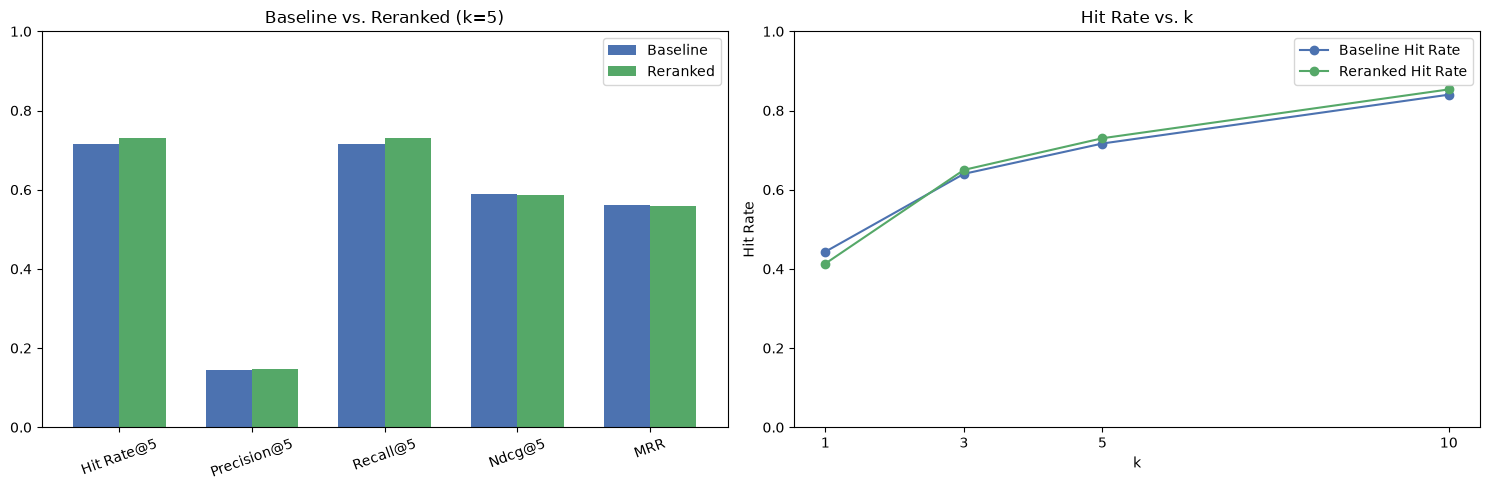

In [12]:
EVAL_K = 5
metrics_at_k = ["hit_rate", "precision", "recall", "ndcg"]

baseline_vals = [results_df[f"{m}@{EVAL_K}"].mean() for m in metrics_at_k] + [results_df["reciprocal_rank"].mean()]
reranked_vals = [results_df_reranked[f"{m}@{EVAL_K}"].mean() for m in metrics_at_k] + [results_df_reranked["reciprocal_rank"].mean()]
labels = [f"{m.replace('_', ' ').title()}@{EVAL_K}" for m in metrics_at_k] + ["MRR"]

x = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(x - width/2, baseline_vals, width, label="Baseline", color="#4C72B0")
axes[0].bar(x + width/2, reranked_vals, width, label="Reranked", color="#55A868")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=20)
axes[0].set_ylim(0, 1)
axes[0].set_title(f"Baseline vs. Reranked (k={EVAL_K})")
axes[0].legend()

for k_target, metric_key in [(k, "hit_rate") for k in K_VALUES]:
    pass  # placeholder to keep structure explicit

baseline_hr = [results_df[f"hit_rate@{k}"].mean() for k in K_VALUES]
reranked_hr = [results_df_reranked[f"hit_rate@{k}"].mean() for k in K_VALUES]
axes[1].plot(K_VALUES, baseline_hr, marker="o", label="Baseline Hit Rate", color="#4C72B0")
axes[1].plot(K_VALUES, reranked_hr, marker="o", label="Reranked Hit Rate", color="#55A868")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Hit Rate")
axes[1].set_ylim(0, 1)
axes[1].set_xticks(K_VALUES)
axes[1].set_title("Hit Rate vs. k")
axes[1].legend()

plt.tight_layout()
plt.show()


If reranking is working as expected, the right-hand chart should show the two lines converging — the reranked curve reaching its high value at a much smaller k than the baseline curve, since reranking's whole job is pulling the correct answer up from deep in the candidate pool toward position 1.

## 9. Latency: What Reranking Costs

Reranking adds a second model call per query. This measures the actual cost so it's an informed tradeoff, not a guess.

In [13]:
def time_calls(fn, n_repeat_queries):
    latencies = []
    for item in n_repeat_queries:
        start = time.perf_counter()
        fn(item["query"])
        latencies.append((time.perf_counter() - start) * 1000)
    return np.array(latencies)


latencies_ms_baseline = time_calls(lambda q: retrieve_for_eval(q, top_k=MAX_K), eval_set)
latencies_ms_reranked = time_calls(lambda q: retrieve_with_reranker(q, candidate_pool_size=CANDIDATE_POOL_SIZE), eval_set)

latency_comparison = pd.DataFrame({
    "baseline_ms": [latencies_ms_baseline.mean(), np.median(latencies_ms_baseline), np.percentile(latencies_ms_baseline, 95)],
    "reranked_ms": [latencies_ms_reranked.mean(), np.median(latencies_ms_reranked), np.percentile(latencies_ms_reranked, 95)],
}, index=["mean", "median", "p95"]).round(1)

latency_comparison["added_ms"] = (latency_comparison["reranked_ms"] - latency_comparison["baseline_ms"]).round(1)
latency_comparison


,baseline_ms,reranked_ms,added_ms
mean,46.0,1900.3,1854.3
median,42.2,1992.1,1949.9
p95,67.7,2057.5,1989.8


## 10. Which Specific Queries Did Reranking Fix?

Aggregate metrics say reranking helped or didn't — this shows exactly which queries flipped, in either direction.

In [14]:
merged = results_df[["query", f"hit_rate@{EVAL_K}"]].merge(
    results_df_reranked[["query", f"hit_rate@{EVAL_K}", "retrieved_doc_ids"]],
    on="query", suffixes=("_baseline", "_reranked")
)

fixed = merged[(merged[f"hit_rate@{EVAL_K}_baseline"] == 0) & (merged[f"hit_rate@{EVAL_K}_reranked"] == 1)]
broken = merged[(merged[f"hit_rate@{EVAL_K}_baseline"] == 1) & (merged[f"hit_rate@{EVAL_K}_reranked"] == 0)]

print(f"Fixed by reranking (miss -> hit @ k={EVAL_K}):  {len(fixed)} queries")
print(f"Broken by reranking (hit -> miss @ k={EVAL_K}): {len(broken)} queries")
print(f"Net change: {len(fixed) - len(broken):+d} queries")

fixed[["query"]].head(10)


Fixed by reranking (miss -> hit @ k=5):  71 queries
Broken by reranking (hit -> miss @ k=5): 48 queries
Net change: +23 queries


,query
6,I have so many issues to address. I have a his...
12,I have so many issues to address. I have a his...
19,I've gone to a couple therapy sessions so far ...
21,I've gone to a couple therapy sessions so far ...
31,How do you know you have the right therapist f...
47,I've gone to a couple therapy sessions so far ...
49,I've gone to a couple therapy sessions so far ...
58,We've been in a long distance relationship for...
61,How does a person start the counseling process?
86,I'm in my late teens and live with my dad. The...


## 11. Stratified Check — Safety-Sensitive Content

Same safety-sensitive breakdown as the baseline notebook, now for both runs — confirm the reranker doesn't help the average at the expense of the highest-stakes slice.

In [15]:
def stratify(df, label):
    out = df.groupby("is_safety_sensitive").agg(
        n_queries=("query", "count"),
        hit_rate=(f"hit_rate@{EVAL_K}", "mean"),
        mrr=("reciprocal_rank", "mean"),
        ndcg=(f"ndcg@{EVAL_K}", "mean"),
    ).round(4)
    out.columns = pd.MultiIndex.from_product([[label], out.columns])
    return out


strat_compare = pd.concat([stratify(results_df, "baseline"), stratify(results_df_reranked, "reranked")], axis=1)
strat_compare


baseline                           reranked           \
                    n_queries hit_rate     mrr    ndcg n_queries hit_rate   
is_safety_sensitive                                                         
False                     293   0.7099  0.5523  0.5795       293   0.7235   
True                        7   1.0000  0.9286  0.9473         7   1.0000   

                                     
                        mrr    ndcg  
is_safety_sensitive                  
False                0.5508  0.5785  
True                 0.9286  0.9473

## 12. Summary & Next Steps

**What to check first:** the `delta` column in Section 8 and the Hit Rate@1 movement specifically — that's the metric this whole exercise targeted. A meaningful positive delta there, with `fixed` clearly outnumbering `broken` in Section 10 and the safety-sensitive slice in Section 11 holding steady or improving, is the signal to actually wire the reranker into the production `RAGRetriever`.

**If the numbers look good:**
1. Wire `retrieve_with_reranker` into the production retrieval path: fetch `CANDIDATE_POOL_SIZE` candidates with the existing bi-encoder, rerank, then apply the production `score_threshold` filtering logic on top of the reranked order (not the raw cosine order).
2. Re-run this notebook with `SAMPLE_SIZE = None` for a final full-corpus confirmation before shipping.
3. Keep an eye on the latency numbers from Section 9 in production — reranking is an extra model call in the critical path, so watch p95/p99 under real load, not just this notebook's single-threaded timings.

**If the lift is small or mixed:**
- Try `BAAI/bge-reranker-base` (larger, generally higher quality) by changing `RERANKER_MODEL_NAME` and re-running Sections 6–11 — everything downstream is already wired to pick up the new model.
- Increase `CANDIDATE_POOL_SIZE` — if the correct document sometimes falls outside the current top 20, no reranker can recover it; check Section 10's `broken`/still-missed queries against their rank in the raw baseline results to see if this is happening.
- Revisit the corpus itself for the topics with the most misses (`strat_topic` from the baseline notebook) — some failures are a retrieval-architecture problem, others are a corpus-quality problem that no retriever change will fix.
